In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset

from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt

import cv2 as cv
import numpy as np

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import random
torch.manual_seed(17)

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


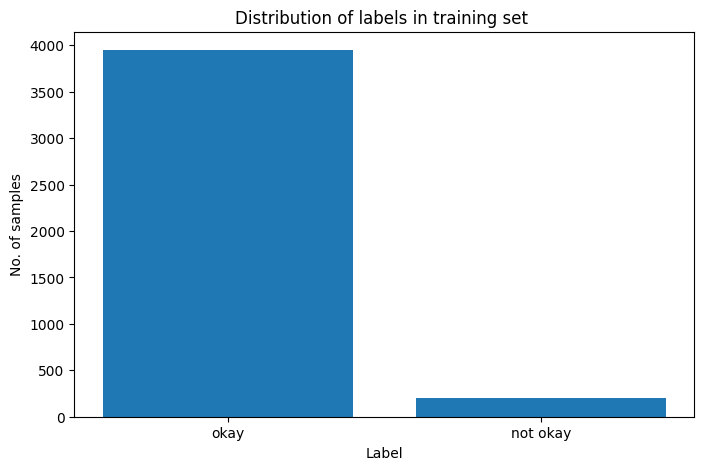

okay =  3948
not okay =  202


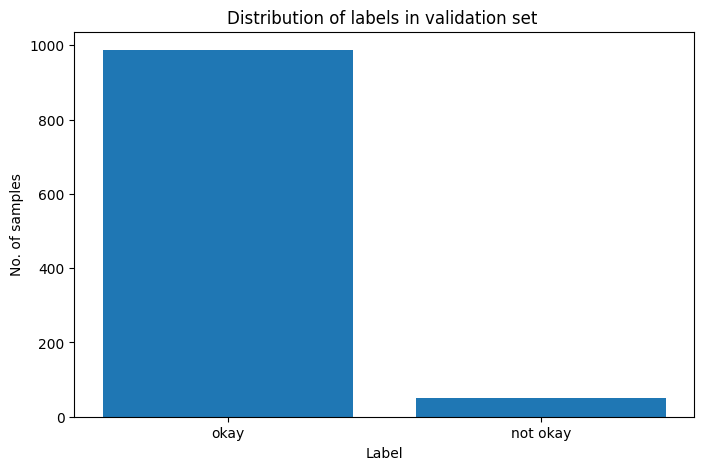

okay =  987
not okay =  51


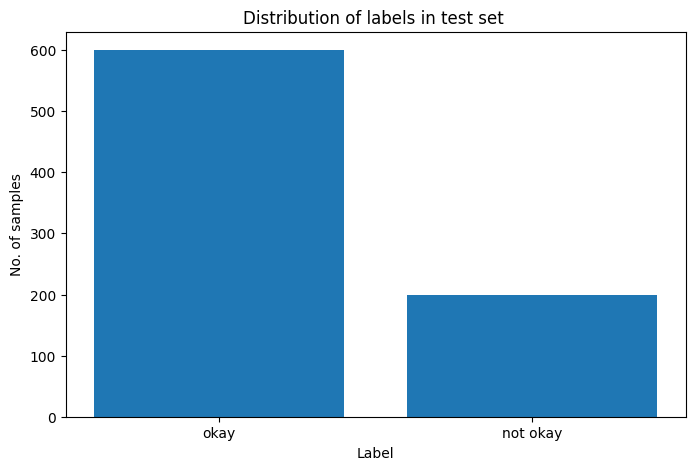

okay =  600
not okay =  200
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0003/1047@View-001@2020-12-7_8-47-29.jpg_Part-0003.jpg
0
image shape =  (377, 338, 3)


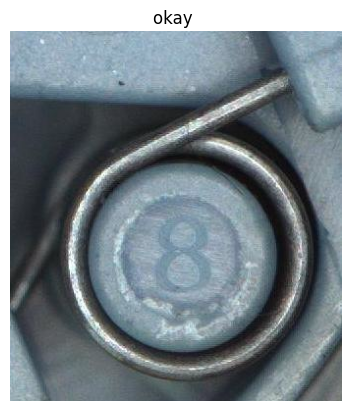

In [3]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/1. First Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()

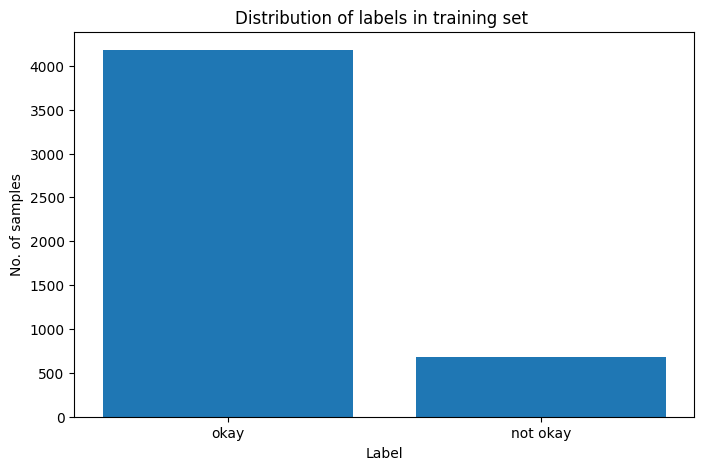

okay =  4179
not okay =  683


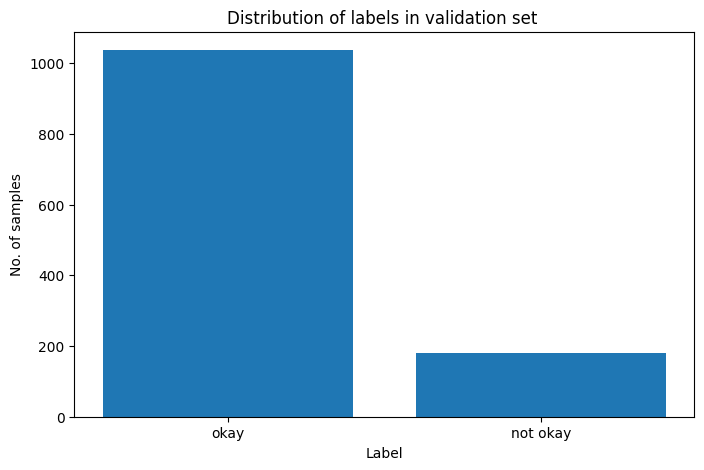

okay =  1037
not okay =  179


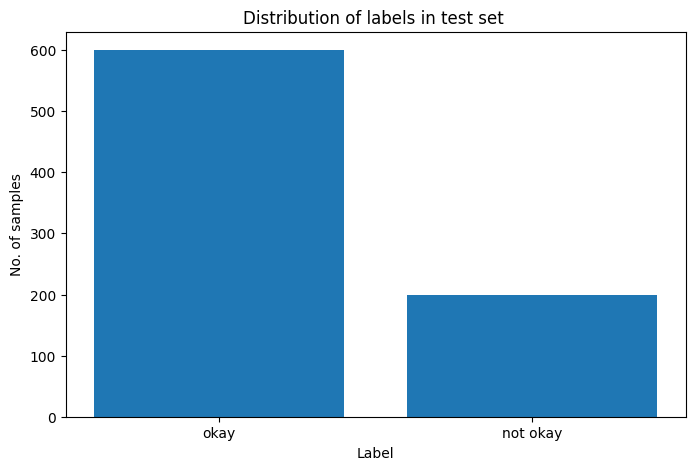

okay =  600
not okay =  200
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0005/0861@View-001@2020-10-29_13-25-16.jpg_Part-0005.jpg
0
image shape =  (204, 438, 3)


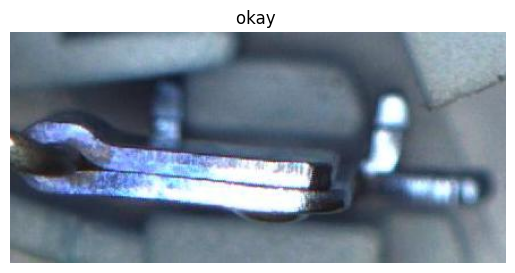

In [4]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/2. Second Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()

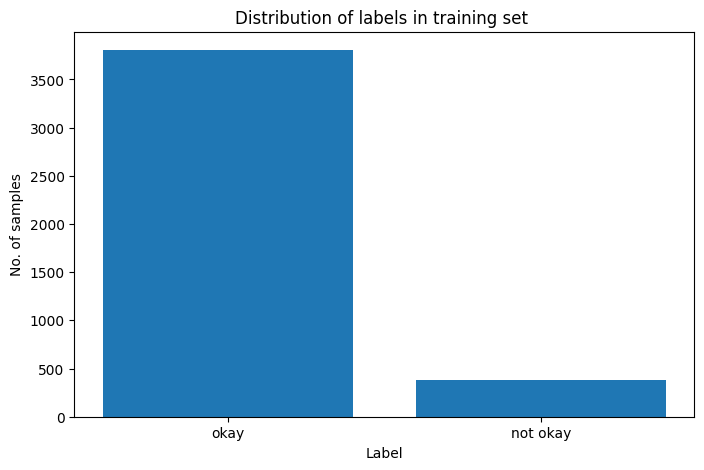

okay =  3805
not okay =  385


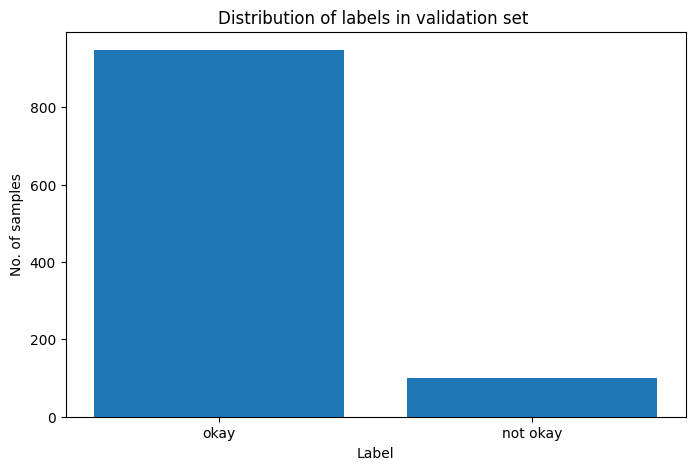

okay =  948
not okay =  100


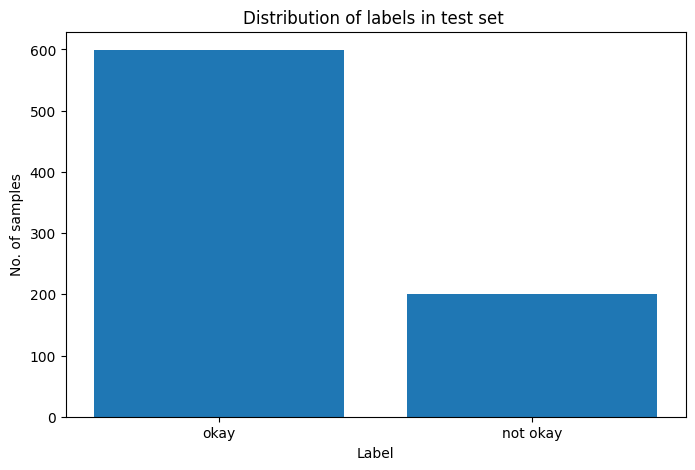

okay =  599
not okay =  201
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0007/0428@View-001@2020-10-23_8-19-57.jpg_Part-0007.jpg
1
image shape =  (530, 462, 3)


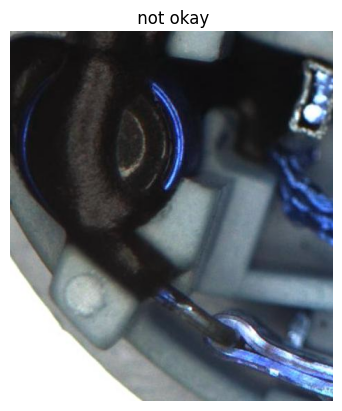

In [5]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/3. Third Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()

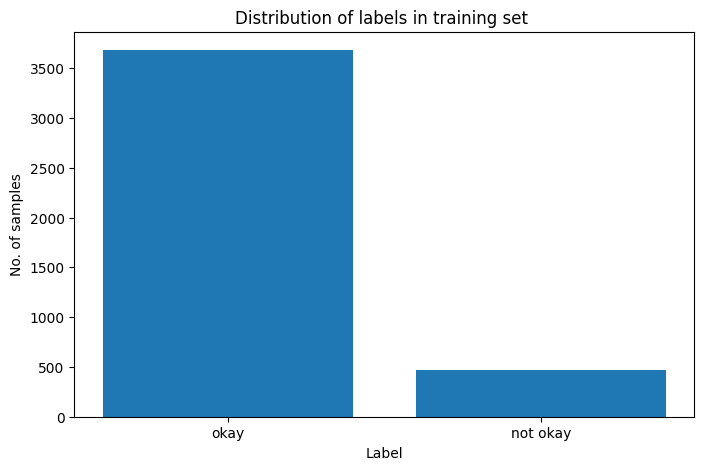

okay =  3682
not okay =  468


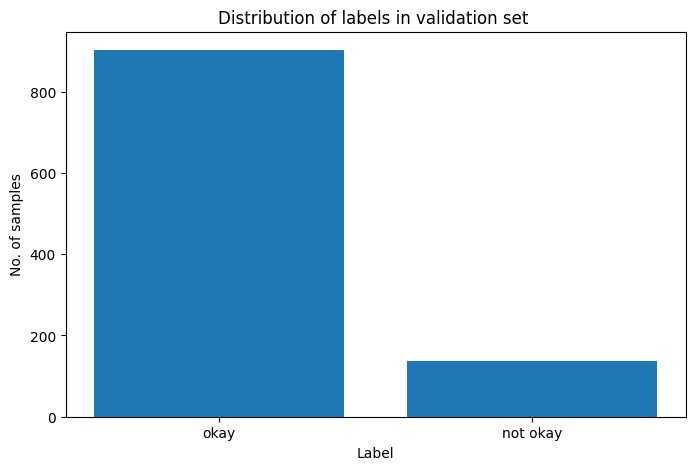

okay =  902
not okay =  136


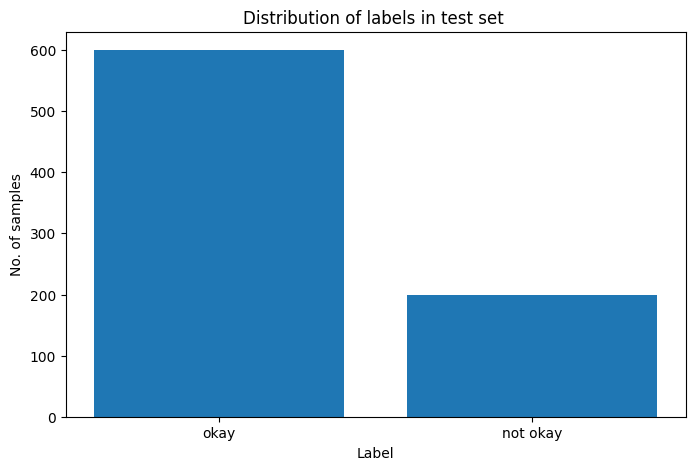

okay =  600
not okay =  200
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0012/1432@View-001@2020-12-7_12-35-48.jpg_Part-0012.jpg
0
image shape =  (210, 201, 3)


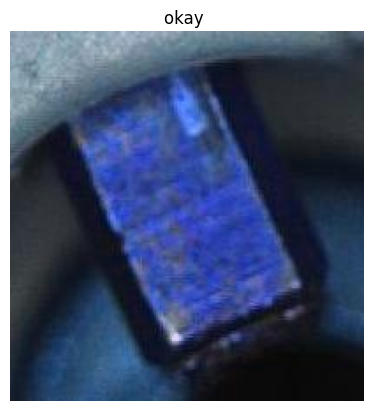

In [6]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/4. Fourth Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()

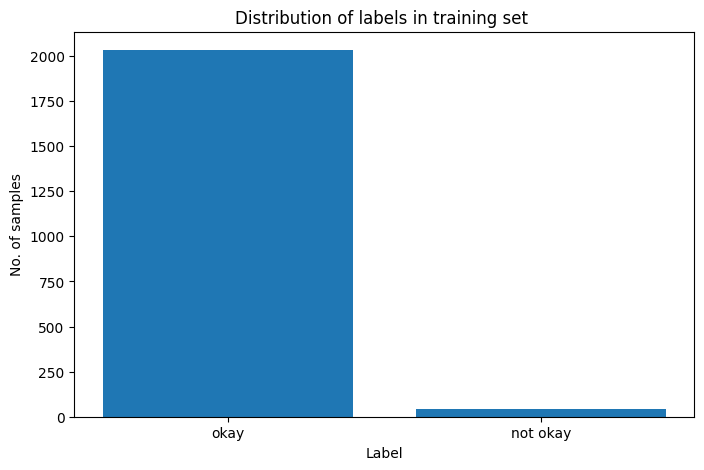

okay =  2033
not okay =  43


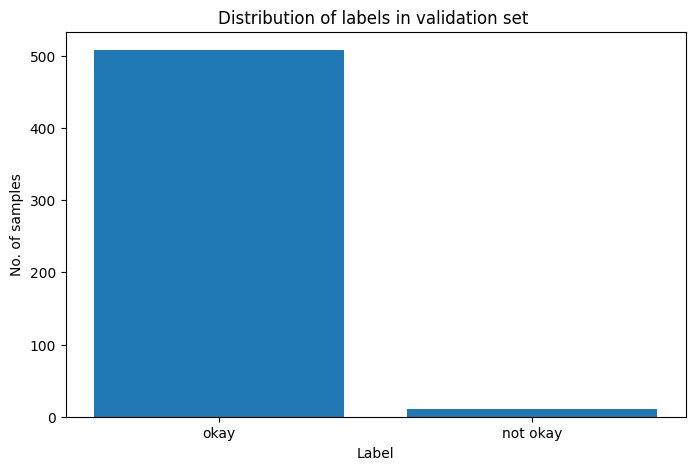

okay =  508
not okay =  11


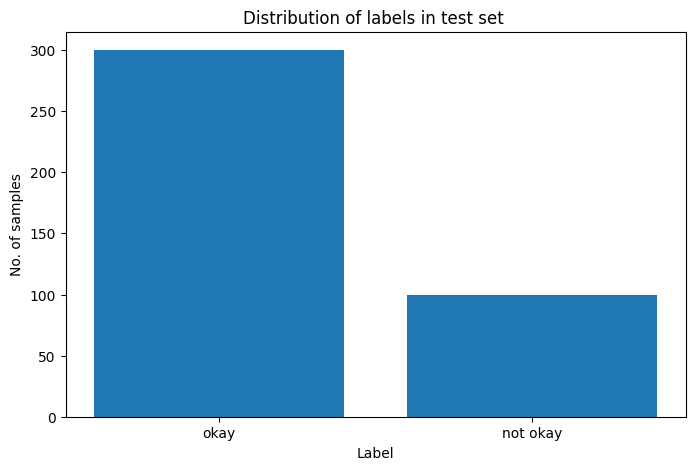

okay =  300
not okay =  100
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0014/0549@View-001@2020-12-1_13-06-34.jpg_Part-0014.jpg
0
image shape =  (444, 429, 3)


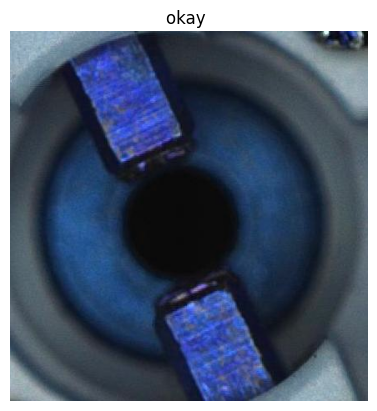

In [7]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/5. Fifth Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()

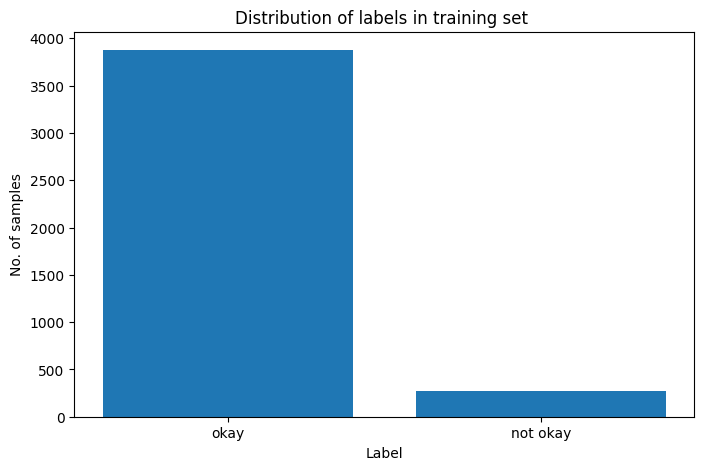

okay =  3876
not okay =  274


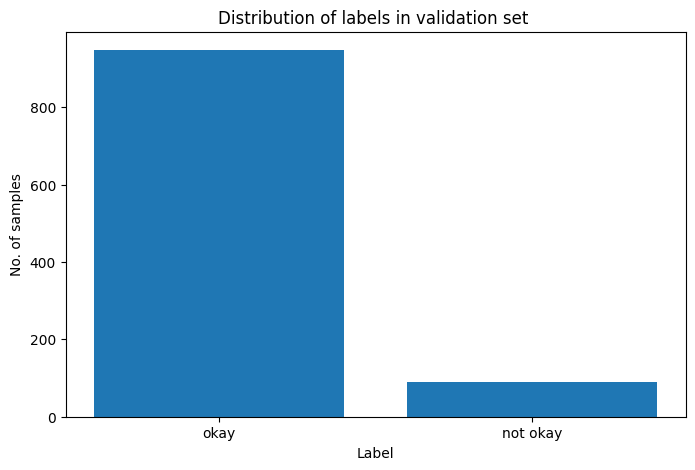

okay =  948
not okay =  90


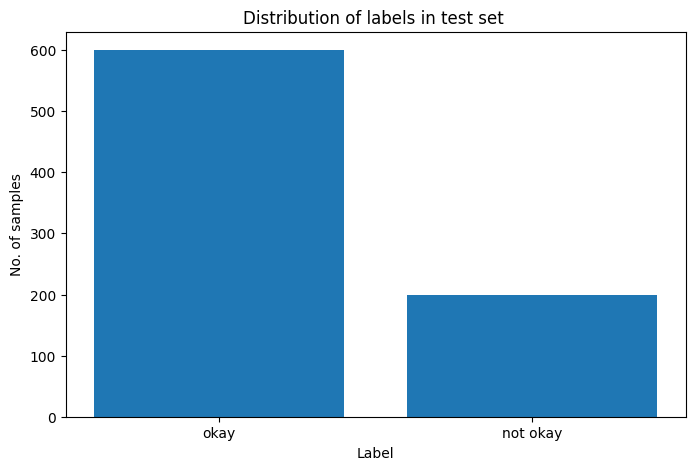

okay =  600
not okay =  200
/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/total_data/Part-0016/0431@View-001@2020-11-28_16-44-59.jpg_Part-0016.jpg
0
image shape =  (158, 167, 3)


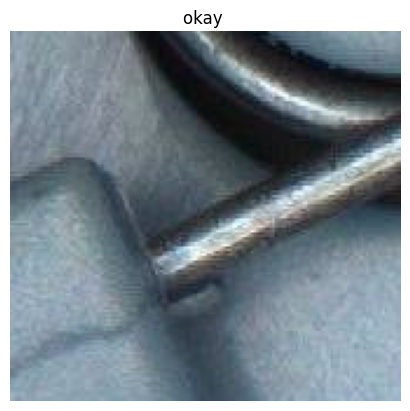

In [8]:
DATA_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/Labels/6. Sixth Part/"

count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in training set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)




count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_val.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in validation set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


count_ok = 0 
count_nok = 0

with open(DATA_DIR+'model_test.txt') as f:
    text = [line for line in f]
    for i in range(len(text)):
        temp = str(text[i]).split()
        #print(temp)
        img_name = temp[0] 
        img_folder = temp[1]
        label = temp[2]
        
        if int(label) ==0:
            count_ok += 1
        else:
            count_nok +=1 
        
fig = plt.figure(figsize = (8, 5)) 
   
number = ["okay", "not okay"]
count = [count_ok, count_nok]
plt.bar(number, count) 
  
plt.xlabel("Label") 
plt.ylabel("No. of samples") 
plt.title("Distribution of labels in test set ") 
plt.show() 

print("okay = ", count_ok)
print("not okay = ", count_nok)


##visualize one of the images 


IMAGE_DIR ="/home/woody/iwfa/iwfa011h/Fangjun_Wang_2021_MBH-dataset/MBH-dataset/"
with open(DATA_DIR+'model_train.txt') as f:
    text = [line for line in f]

temp = str(text[0]).split()

#print(temp)
img_name = temp[0] 
img_folder = temp[1]
label = temp[2]
label = int(label)
        
image_path = IMAGE_DIR + "total_data/"+ str(img_folder) + "/"+ img_name
print(image_path)
print(label)
image = cv.imread(image_path)

#print(type(image))
#image.resize(224, 224, 3)
print("image shape = ", image.shape)
if int(label == 0): 
    label = "okay "
else: 
    label = " not okay"
    
plt.imshow(image)
plt.axis("off")
plt.title(str(label))
plt.show()